#Red neuronal - Predicción de enfermedad: Diabetes

Esta es una rednneuronal enfocada en la predicción de sufrur una enfermedad como la diabetes y que sea controlado a tiempo, esto mediante algoritmos de predicción.

Todo a modo de practica y autoestudio, elaborado por: Luis Felipe Sanchez Sanchez

##Alistamiento de datos iniciales

Importamos librerias

In [6]:
#Importamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Conectamos con Drive

In [7]:
#Conectamos con google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#Importamos los datos
data = pd.read_csv('/content/drive/MyDrive/Ejecicios de practica/Red-Predicción-Diabetes/diabetes_prediction_india.csv')

In [9]:
data

,Age,Gender,BMI,Family_History,Physical_Activity,Diet_Type,Smoking_Status,Alcohol_Intake,Stress_Level,Hypertension,...,Health_Insurance,Regular_Checkups,Medication_For_Chronic_Conditions,Pregnancies,Polycystic_Ovary_Syndrome,Glucose_Tolerance_Test_Result,Vitamin_D_Level,C_Protein_Level,Thyroid_Condition,Diabetes_Status
0,48,Male,35.5,No,High,Non-Vegetarian,Never,NaN,Medium,Yes,...,No,No,No,0,0,124.3,31.5,7.46,Yes,Yes
1,18,Other,28.7,Yes,Medium,Non-Vegetarian,Current,Moderate,High,No,...,Yes,Yes,No,0,0,151.4,12.5,5.64,Yes,No
2,21,Other,30.0,Yes,High,Non-Vegetarian,Current,Moderate,High,Yes,...,No,No,Yes,0,0,106.1,35.8,7.20,No,Yes
3,25,Female,25.6,No,Medium,Vegetarian,Former,Moderate,High,Yes,...,No,No,Yes,1,No,85.6,15.4,6.53,Yes,No
4,78,Male,38.8,No,High,Non-Vegetarian,Current,High,High,No,...,No,No,Yes,0,0,77.0,28.6,0.58,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5287,35,Male,39.0,No,High,Vegan,Never,Moderate,Low,Yes,...,Yes,No,Yes,0,0,174.6,16.3,5.48,Yes,No
5288,44,Other,32.0,Yes,Low,Vegetarian,Never,Moderate,High,Yes,...,Yes,Yes,No,0,0,119.3,32.4,7.39,Yes,Yes
5289,55,Male,22.3,No,High,Non-Vegetarian,Current,NaN,Low,Yes,...,No,No,Yes,0,0,143.6,43.3,7.24,Yes,Yes
5290,65,Other,21.7,Yes,High,Non-Vegetarian,Former,NaN,Low,Yes,...,No,No,Yes,0,0,79.8,22.2,4.00,No,Yes


In [10]:
#Creamos copia del dataset para modificarlo
df = data.copy()

##Limpieza de datos

###Matriz de sombras

In [11]:
#Matriz  de sombras
df.isna()

,Age,Gender,BMI,Family_History,Physical_Activity,Diet_Type,Smoking_Status,Alcohol_Intake,Stress_Level,Hypertension,...,Health_Insurance,Regular_Checkups,Medication_For_Chronic_Conditions,Pregnancies,Polycystic_Ovary_Syndrome,Glucose_Tolerance_Test_Result,Vitamin_D_Level,C_Protein_Level,Thyroid_Condition,Diabetes_Status
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5287,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5288,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5289,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5290,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


###Eliminamos registros de datos faltantes

Eliminamos los datos faltantes para evitar resultados inconsistentes en el proceso de analizis y visualización de datosa, asi mismo, para lograr una buena predicción

In [12]:
df.describe()

,Age,BMI,Cholesterol_Level,Fasting_Blood_Sugar,Postprandial_Blood_Sugar,HBA1C,Heart_Rate,Waist_Hip_Ratio,Pregnancies,Glucose_Tolerance_Test_Result,Vitamin_D_Level,C_Protein_Level
count,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000,5292.000000
mean,48.417989,27.459883,199.777098,124.940193,164.709902,8.226909,89.787415,0.949399,1.493386,135.011867,29.909883,5.258743
std,18.040544,7.194187,57.103759,32.091770,43.152803,2.179662,17.238430,0.144871,2.677414,37.541696,11.527951,2.754500
min,18.000000,15.000000,100.000000,70.000000,90.100000,4.500000,60.000000,0.700000,0.000000,70.100000,10.000000,0.500000
25%,33.000000,21.200000,151.100000,97.100000,128.175000,6.300000,75.000000,0.820000,0.000000,102.175000,20.000000,2.880000
50%,48.000000,27.400000,198.600000,124.050000,164.950000,8.200000,90.000000,0.950000,0.000000,136.000000,29.800000,5.270000
75%,64.000000,33.600000,249.100000,153.300000,201.000000,10.100000,105.000000,1.080000,2.000000,167.100000,39.900000,7.660000
max,79.000000,40.000000,300.000000,180.000000,240.000000,12.000000,119.000000,1.200000,9.000000,200.000000,50.000000,10.000000


In [13]:
df.dtypes

,0
Age,int64
Gender,object
BMI,float64
Family_History,object
Physical_Activity,object
Diet_Type,object
Smoking_Status,object
Alcohol_Intake,object
Stress_Level,object
Hypertension,object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5292 entries, 0 to 5291
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                5292 non-null   int64  
 1   Gender                             5292 non-null   object 
 2   BMI                                5292 non-null   float64
 3   Family_History                     5292 non-null   object 
 4   Physical_Activity                  5292 non-null   object 
 5   Diet_Type                          5292 non-null   object 
 6   Smoking_Status                     5292 non-null   object 
 7   Alcohol_Intake                     3512 non-null   object 
 8   Stress_Level                       5292 non-null   object 
 9   Hypertension                       5292 non-null   object 
 10  Cholesterol_Level                  5292 non-null   float64
 11  Fasting_Blood_Sugar                5292 non-null   float

In [15]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Family_History,0
Physical_Activity,0
Diet_Type,0
Smoking_Status,0
Alcohol_Intake,1780
Stress_Level,0
Hypertension,0


In [16]:
#eliminnamos los registros cuando se presentan datos faltantes
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3512 entries, 1 to 5291
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                3512 non-null   int64  
 1   Gender                             3512 non-null   object 
 2   BMI                                3512 non-null   float64
 3   Family_History                     3512 non-null   object 
 4   Physical_Activity                  3512 non-null   object 
 5   Diet_Type                          3512 non-null   object 
 6   Smoking_Status                     3512 non-null   object 
 7   Alcohol_Intake                     3512 non-null   object 
 8   Stress_Level                       3512 non-null   object 
 9   Hypertension                       3512 non-null   object 
 10  Cholesterol_Level                  3512 non-null   float64
 11  Fasting_Blood_Sugar                3512 non-null   float64
 1

###Eliminamos columnas irrelevantes


Para este caso eliminamos las columnas de BHA1C, Urban_Rural y Health_Insurance. Dado que para lo que estamos realizando no son relevantes en el proceso

In [17]:
df.drop(['HBA1C', 'Urban_Rural', 'Health_Insurance'], axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3512 entries, 1 to 5291
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                3512 non-null   int64  
 1   Gender                             3512 non-null   object 
 2   BMI                                3512 non-null   float64
 3   Family_History                     3512 non-null   object 
 4   Physical_Activity                  3512 non-null   object 
 5   Diet_Type                          3512 non-null   object 
 6   Smoking_Status                     3512 non-null   object 
 7   Alcohol_Intake                     3512 non-null   object 
 8   Stress_Level                       3512 non-null   object 
 9   Hypertension                       3512 non-null   object 
 10  Cholesterol_Level                  3512 non-null   float64
 11  Fasting_Blood_Sugar                3512 non-null   float64
 1

### Filas repetidas

Validamos si existe algun registro que este duplicado, y en caso de haberlo, procedemos a  eliminarlo

In [18]:
df.duplicated().sum()
#No hay ningun registro duplicado, por tal motivo no se elimina ni toca nada

np.int64(0)

###Inconsistencias ortograficas

Aca se busca analizar que las columnas tengan los valores correctos escritos de una una forma adecuada para evitar duplicados o errores

In [19]:
# print(df.Gender.unique())
# print(df.Family_History.unique())
# print(df.Physical_Activity.unique())
# print(df.Diet_Type.unique())
# print(df.Smoking_Status.unique())
# print(df.Alcohol_Intake.unique())
# print(df.Stress_Level.unique())
# print(df.Hypertension.unique())
# print(df.Regular_Checkups.unique())
# print(df.Medication_For_Chronic_Conditions.unique())
# print(df.Polycystic_Ovary_Syndrome.unique())
# print(df.Thyroid_Condition.unique())
# print(df.Diabetes_Status.unique())


variablesCategoricas = ['Gender', 'Family_History', 'Physical_Activity', 'Diet_Type', 'Smoking_Status','Alcohol_Intake', 'Stress_Level', 'Hypertension', 'Regular_Checkups', 'Medication_For_Chronic_Conditions', 'Polycystic_Ovary_Syndrome', 'Thyroid_Condition', 'Diabetes_Status']
# print(variablesCategoricas)

for i in variablesCategoricas:
  print(i)
  print(df[i].unique())

Gender
['Other' 'Female' 'Male']
Family_History
['Yes' 'No']
Physical_Activity
['Medium' 'High' 'Low']
Diet_Type
['Non-Vegetarian' 'Vegetarian' 'Vegan']
Smoking_Status
['Current' 'Former' 'Never']
Alcohol_Intake
['Moderate' 'High']
Stress_Level
['High' 'Medium' 'Low']
Hypertension
['No' 'Yes']
Regular_Checkups
['Yes' 'No']
Medication_For_Chronic_Conditions
['No' 'Yes']
Polycystic_Ovary_Syndrome
['0' 'No' 'Yes']
Thyroid_Condition
['Yes' 'No']
Diabetes_Status
['No' 'Yes']


Como vemos hay un 0 en la variable Polycystic_Ovary_Syndrome, asi que tomaremos ese 0 como "No" para seguir manejando la misma secuencia de datos

In [20]:
df.Polycystic_Ovary_Syndrome.value_counts()

,count
Polycystic_Ovary_Syndrome,
0,2340
Yes,592
No,580


In [21]:
#reemplazamos el 0 de la columna Polycystic_Ovary_Syndrome a un NNo
df['Polycystic_Ovary_Syndrome'] = df['Polycystic_Ovary_Syndrome'].replace('0', 'No')


In [22]:
df.Polycystic_Ovary_Syndrome.value_counts()

,count
Polycystic_Ovary_Syndrome,
No,2920
Yes,592


##Analisis de datos

In [23]:
df

,Age,Gender,BMI,Family_History,Physical_Activity,Diet_Type,Smoking_Status,Alcohol_Intake,Stress_Level,Hypertension,...,Waist_Hip_Ratio,Regular_Checkups,Medication_For_Chronic_Conditions,Pregnancies,Polycystic_Ovary_Syndrome,Glucose_Tolerance_Test_Result,Vitamin_D_Level,C_Protein_Level,Thyroid_Condition,Diabetes_Status
1,18,Other,28.7,Yes,Medium,Non-Vegetarian,Current,Moderate,High,No,...,0.96,Yes,No,0,No,151.4,12.5,5.64,Yes,No
2,21,Other,30.0,Yes,High,Non-Vegetarian,Current,Moderate,High,Yes,...,0.88,No,Yes,0,No,106.1,35.8,7.20,No,Yes
3,25,Female,25.6,No,Medium,Vegetarian,Former,Moderate,High,Yes,...,0.98,No,Yes,1,No,85.6,15.4,6.53,Yes,No
4,78,Male,38.8,No,High,Non-Vegetarian,Current,High,High,No,...,0.85,No,Yes,0,No,77.0,28.6,0.58,No,Yes
6,38,Female,36.4,Yes,Medium,Vegetarian,Current,High,Medium,No,...,1.11,No,Yes,2,No,78.6,11.7,8.24,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5284,60,Other,17.3,No,Medium,Non-Vegetarian,Former,Moderate,Low,Yes,...,0.91,Yes,Yes,0,No,180.2,49.0,9.06,No,Yes
5286,72,Other,36.7,Yes,Medium,Non-Vegetarian,Current,Moderate,Low,Yes,...,1.10,Yes,Yes,0,No,135.1,12.6,5.07,Yes,Yes
5287,35,Male,39.0,No,High,Vegan,Never,Moderate,Low,Yes,...,1.05,No,Yes,0,No,174.6,16.3,5.48,Yes,No
5288,44,Other,32.0,Yes,Low,Vegetarian,Never,Moderate,High,Yes,...,0.92,Yes,No,0,No,119.3,32.4,7.39,Yes,Yes


In [25]:
#Analizamos todas las columans
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3512 entries, 1 to 5291
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                3512 non-null   int64  
 1   Gender                             3512 non-null   object 
 2   BMI                                3512 non-null   float64
 3   Family_History                     3512 non-null   object 
 4   Physical_Activity                  3512 non-null   object 
 5   Diet_Type                          3512 non-null   object 
 6   Smoking_Status                     3512 non-null   object 
 7   Alcohol_Intake                     3512 non-null   object 
 8   Stress_Level                       3512 non-null   object 
 9   Hypertension                       3512 non-null   object 
 10  Cholesterol_Level                  3512 non-null   float64
 11  Fasting_Blood_Sugar                3512 non-null   float64
 1

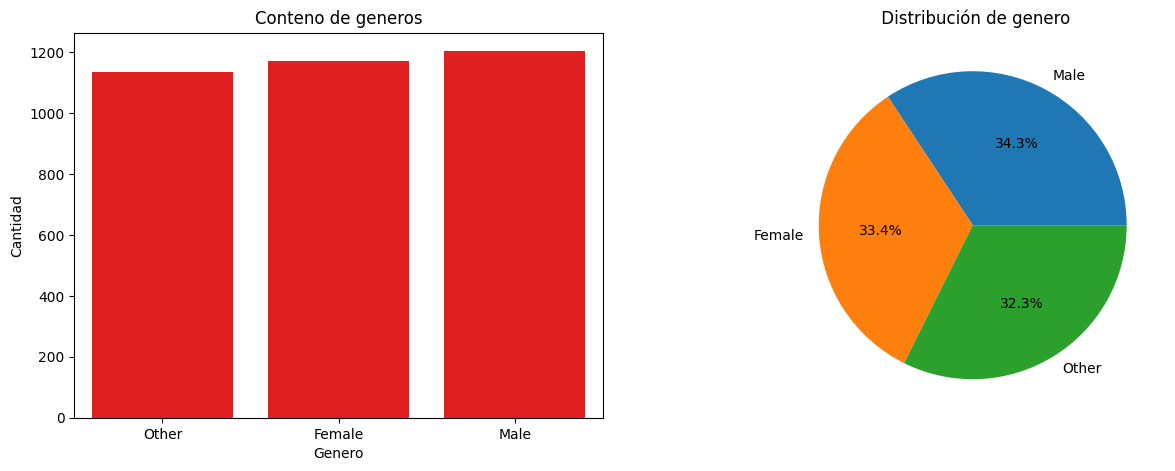

In [54]:
#Grafica para saber el gender del df
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.countplot(x='Gender', data=df, color='r')
plt.title('Conteno de generos')
plt.xlabel('Genero')
plt.ylabel('Cantidad')

plt.subplot(1,2,2)
plt.pie(df['Gender'].value_counts(), labels=df['Gender'].value_counts().index, autopct='%1.1f%%')
plt.title(' Distribución de genero')

plt.show()

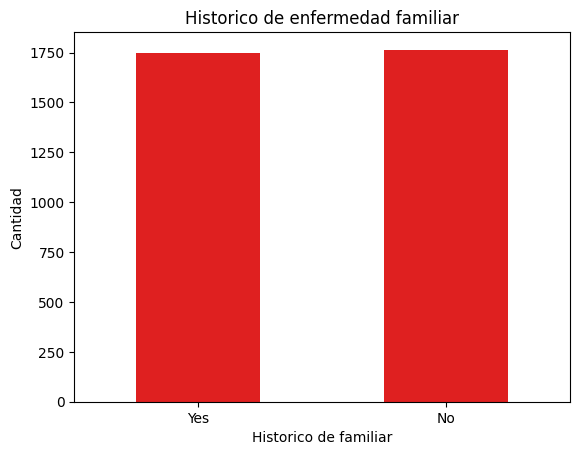

In [70]:
#Saber cuanta gente tiene historico familiar de enfermedad y cuanta no

sns.countplot(x='Family_History', data=df, color='r', width=0.5)
plt.title('Historico de enfermedad familiar')
plt.xlabel('Historico de familiar')
plt.ylabel('Cantidad')
plt.show()

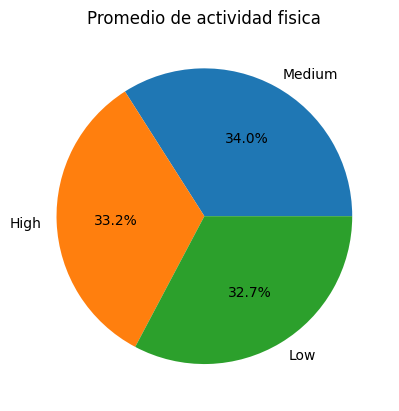

In [64]:
#Porcentaje de personas con actividad fisica
plt.pie(df['Physical_Activity'].value_counts(), labels=df['Physical_Activity'].value_counts().index, autopct='%1.1f%%')
plt.title('Promedio de actividad fisica')
plt.show()

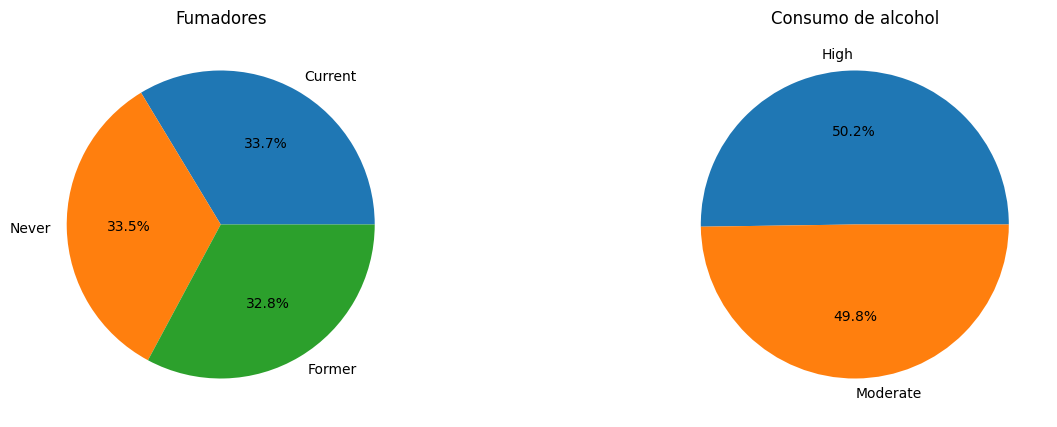

In [69]:
#Consumo de tabaco vs consumo de alcohol
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.pie(df['Smoking_Status'].value_counts(), labels=df['Smoking_Status'].value_counts().index, autopct='%1.1f%%')
plt.title('Fumadores')

plt.subplot(1,2,2)
plt.pie(df['Alcohol_Intake'].value_counts(), labels=df['Alcohol_Intake'].value_counts().index, autopct='%1.1f%%')
plt.title('Consumo de alcohol')

plt.show()

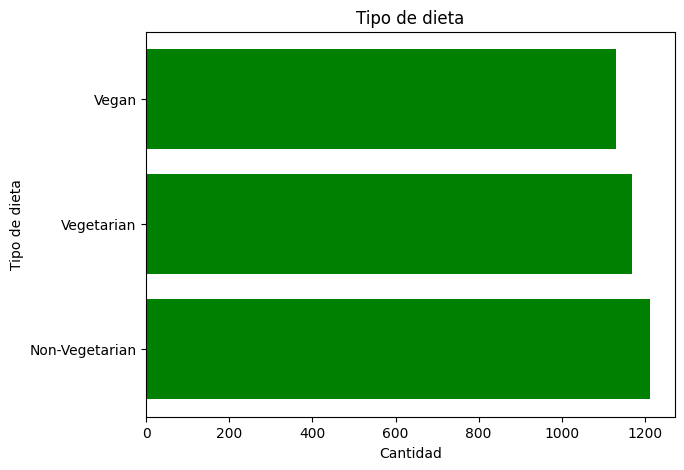

In [75]:
#Grafica para medir el diet_type "Tipo de dieta"
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.barh(y=df['Diet_Type'].value_counts().index, width=df['Diet_Type'].value_counts().values, color='g')
plt.title('Tipo de dieta')
plt.xlabel('Cantidad')
plt.ylabel('Tipo de dieta')
plt.show()